In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pycontrails import Fleet

In [ ]:
dff = pd.read_parquet("../data/filed_matthes_2025_dahlmann_2025_EAGWP100_[0, 1000].parquet")
fleetf = Fleet(data=dff)
print(f"Fleet contains {fleetf.n_flights} flights")

dfo = pd.read_parquet("../data/optimised_matthes_2025_dahlmann_2025_EAGWP100_[0, 1000].parquet")
fleeto = Fleet(data=dfo)
print(f"Fleet contains {fleeto.n_flights} flights")

Fleet contains 4112 flights
Fleet contains 4112 flights


In [3]:
from cane.utils import mask_by_marker

mask_by_marker(fleetf, ["nox", "NOx", "O3", "CH4"])
mask_by_marker(fleeto, ["nox", "NOx", "O3", "CH4"])

dff = fleetf.dataframe
dfo = fleeto.dataframe

Marked rows filtered out for nox
Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4
Marked rows filtered out for nox
Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4


/var/folders/rf/y26fjyd9451bv4jwfbfwvy_j1vr8st/T/ipykernel_52309/3603117109.py:55: MatplotlibDeprecationWarning: Since Matplotlib 3.10 indicate_inset_[zoom] returns a single InsetIndicator artist with a rectangle property and a connectors property.  From 3.12 it will no longer be possible to unpack the return value into two elements.
  rect, connectors = axes[0].indicate_inset_zoom(axes[1], edgecolor="red")


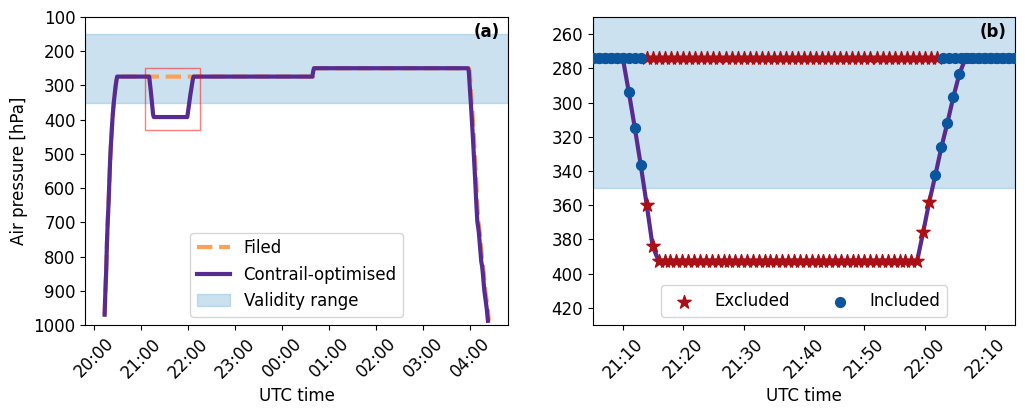

In [ ]:
import matplotlib.dates as mdates
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, inset_axes

fid = "b5cd68349d90565e70c5c0106fb5624709049d9e"
ff = dff.query("flight_id == @fid")
fo = dfo.query("flight_id == @fid")

fig, axes = plt.subplots(ncols=2, figsize=(12, 4))

for ax in axes:
    ax.plot(ff.time, ff.pressure, label="Filed", linestyle="--", linewidth=3, color=sns.color_palette("Oranges")[2])
    ax.plot(fo.time, fo.pressure, label="Contrail-optimised", linewidth=3, color=sns.color_palette("Purples")[5])
    ax.axhspan(150, 350, alpha=0.3, label="Validity range", color=sns.color_palette("Blues")[3])

    # x axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  #%Y-%m-%d
    plt.setp(ax.get_xticklabels(), rotation=45)  #, ha='right')
    ax.set_xlabel("UTC time", fontsize=12)

    # y axis
    ax.yaxis.set_inverted(True)

    # fontsize
    ax.tick_params(labelsize=12)

# Scatter dots, only every second dot [1::2] or [::2]
mask = ff["is_excluded"]
axes[1].scatter(ff.time[mask], ff.pressure[mask], marker='*', color=sns.color_palette("Reds")[5], zorder=5,
                s=100,
                label="Excluded")
axes[1].scatter(ff.time[~mask], ff.pressure[~mask], marker='o', color=sns.color_palette("Blues")[5],
                zorder=5,
                s=50,
                label="Included")

mask = fo["is_excluded"]
axes[1].scatter(fo.time[mask], fo.pressure[mask], marker='*', color=sns.color_palette("Reds")[5], zorder=5,
                s=100)
axes[1].scatter(fo.time[~mask], fo.pressure[~mask], marker='o', color=sns.color_palette("Blues")[5],
                zorder=5,
                s=50)

# Zoom in
axes[0].set_ylabel("Air pressure [hPa]", fontsize=12)
axes[0].set_ylim([1000, 100])

axes[1].set_xlim([pd.Timestamp("2023-09-17 21:05:00"), pd.Timestamp("2023-09-17 22:15:00")])
axes[1].set_ylim([430, 250])

handles, labels = axes[1].get_legend_handles_labels()
axes[0].legend(loc='lower center', ncol=1, fontsize=12)
axes[1].legend(handles=handles[3:], labels=labels[3:], loc='lower center', ncol=2, fontsize=12)

# Draw a box on ax_left showing the zoomed region
rect, connectors = axes[0].indicate_inset_zoom(axes[1], edgecolor="red")
for c in connectors:
    c.set_visible(False)

axes[0].text(
    0.98, 0.98, "(a)",
    transform=axes[0].transAxes,
    fontsize=12, fontweight="bold",
    va="top", ha="right"
)

axes[1].text(
    0.98, 0.98, "(b)",
    transform=axes[1].transAxes,
    fontsize=12, fontweight="bold",
    va="top", ha="right"
)

plt.savefig("figures/figC2.png", dpi=300, bbox_inches="tight")

In [5]:
print(dff.query("is_excluded == True").flight_id.nunique(), "total affected flights")

564 total affected flights
